# Estudio comparativo de la familia de algoritmos de UCB (Upper Confidence Bound)

## Introducción

Son numerosos los algoritmos de existentes para resolver la gran problemática del bandido de los k brazos. Dentro de todo el grupo de algoritmos existentes, destaca la proposición de Agrawal [[1]](#apuntes) que propone explorar clases genéricas de políticas de índice basadas en el análisis de los límites superiores de confianza (Upper Confidence Bound).

La idea propuesta resulta en cierta manera sencilla de asimilar, dado que la proposición pasa por medir el potencial de cada brazo con un índice de política que está formado por la suma de sus terminos, es decir:

$$ucb(a) = Q(a) + u(a)$$

Donde $Q(a)$ queda definido el termino de exploración y donde $u(a)$ queda definido el límite superior del termino de exploración y el término $a$ es la acción candidata.

A terminos generales se puede extrapolar $Q(a)$ a $Q_t(a)$, en la que esta última es una función que estima la acción $a$ en el instante de tiempo $t$

El objetivo de esta propuesta es de mitigar los problemas del algoritmo $\epsilon$ greedy, dado que este algoritmo tiene tendencia a explorar de forma rudimentaria aquellas acciones que no sean las más indicadas, mientras que la proposición UCB resulta en un equilibrio entre los valores conocidos y la incertidumbre existente del problema.

La acción a elegir siempre va a pasar por aquella acción dentro de todas las candidatas que maximice el valor de UCB, es decir:

$$a_t = \arg\max_{a \in A} \mathrm{ucb}(a)$$

El primer algoritmo de la familia de algoritmos UCB se denomina UCB1 y define la función $u(a)$ de la siguente manera:

$$u(a)=\epsilon=\sqrt{\frac{1}{2N_t(a)}ln\frac{2}{\alpha}}=\sqrt{\frac{1}{2N_t(a)}ln(t)^4}=\sqrt{\frac{ln(t)}{N_t(a)}}$$

Así mismo, podemos añadir a la función $u(a)$ un parámetro de aajuste para controlar el grado de exploración, quedando la formula final de la siguietne manera:

$$UCB1(a)=Q(a) + c\sqrt{\frac{ln(t)}{N(a)}}$$

Como lo que queremos hacer es obtener aquella acción que nos maximice nuestro valor UCB1, la solución queda de la siguiente manera:


$$A_t = \arg\max_{a \in A} \mathrm{Q_t}(a) + c\sqrt{\frac{ln(t)}{N(a)}}$$

En una posterior revisión del algoritmo UCB, Peter Auer propone la segunda iteración del mismo, denominado UCB2, en la que la fórmula para calcular $u(a)$ se ve modificado en gran manera:

$$UCB2(a)=Q(a)+\sqrt{\frac{(1+\alpha)ln(\frac{e\cdot t}{\tau(k_a)})}{2\tau(k_a)}}$$

Donde $\alpha$ es el parámetro ajustable para el balance entre exploración y explotación comprendido en el rango $(0,1)$

Donde $\tau(k_a)$ representa el número de veces que la acción $a$ será seleccionado en una época definido mediante:

$$\tau(k_a)=\lceil(1+\alpha)^{k_a}\rceil$$

En una nueva iteración, se propone el uso de las varianzas empíricas aplicadas a las recompensas acumuladas cuyo cálculo queda de la siguiente manera:

$$V(a)=\frac{1}{N(a)}\sum_{i=1}^{N(a)} (r_i - Q(a))^2$$

Con esta información la fórmula de UCB1 original queda reescrita para que quede de la siguiente manera:

$$UCB1_{tuned}(a)=Q(a)+\sqrt{\frac{ln(t)}{N(a)}\cdot mín\left(\frac{1}{4},V(a)+\sqrt{\frac{2ln(t)}{N(a)}} \right)}$$

Dado que la fórmula de la varianza planteada tiene un coste computacional que crece significativamente conforme más acciones son ejecutadas, esta va a ser replanteada con la definición de la varianza, es decir:

$$
\begin{align}
Var(X) = \mathbb{E}\left[(X-\mathbb{E}[X])^2\right]
&= \mathbb{E}\left[X^2-2X\mathbb{E}[X]+\mathbb{E}[X]^2\right] \\
&= \mathbb{E}[X^2] - 2\mathbb{E}[X]\mathbb{E}[X]+\mathbb{E}[X]^2 \\
&= \mathbb{E}[X^2] - 2\mathbb{E}[X]^2 + \mathbb{E}[X]^2 \\
&= \mathbb{E}[X^2] - \mathbb{E}[X]^2
\end{align}
$$

Es decir, utilizaremos la media de los cuadrados de los valores de las recompensas, que son X menos el cuadrado de la media de las recompensas una solución de computo bastante más sencilla y una aproximación bastante buena.

## Preparación del entorno

In [1]:
# Librerías necesarias para el setup
import sys, os

En función de si el notebook se va a ejecutar en local (dentro del repositorio clonado de GitHub), o bien en Google Colab, se debe ejecutar una de las dos siguientes subsecciones.

###  Setup para la ejecución en Colab

In [2]:
# Clonar el repositorio

In [3]:
# Añadir los directorio fuentes al path de Python

### Setup para la ejecución en local

In [4]:
# Añadir el directorio src al path para importar los módulos
src_path = os.path.abspath(os.path.join(os.getcwd(), 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)
    
print(sys.path)

['C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.13_3.13.2544.0_x64__qbz5n2kfra8p0\\python313.zip', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.13_3.13.2544.0_x64__qbz5n2kfra8p0\\DLLs', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.13_3.13.2544.0_x64__qbz5n2kfra8p0\\Lib', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.13_3.13.2544.0_x64__qbz5n2kfra8p0', 'c:\\Users\\jorge\\EML_RL_LucasOrtiz\\.venv', '', 'c:\\Users\\jorge\\EML_RL_LucasOrtiz\\.venv\\Lib\\site-packages', 'c:\\Users\\jorge\\EML_RL_LucasOrtiz\\k_brazos\\src']


### Importación de librerías y módulos

In [5]:
import numpy as np

from algorithms import UCB1, UCB2, UCB1Tuned
from arms import Bandit, ArmNormal, ArmBinomial, ArmBernoulli
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics
from run_experiment import run_experiment

## Parámetros generales

En la siguiente celda vamos a establecer algunos parámetros comunes a todos los experimentos, es necesario establecer una semilla para asegurar reproducibilidad de los resultados. El uso de bandidos con 6 brazos es sugerido para que las gráficas estadísticas resulten bastante más asumibles visualmente. En total, cada ejecución constará de 300 pasos puesto a que se ha comprobado que todos los algoritmos realizan la convergencia antes de este número de iteraciones, y cada experimento será repetido en total unas 500 veces.

In [6]:
SEMILLA = 1024

k = 6  # Número de brazos
steps = 300  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

## Creación de los bandidos

En est sección se crean los 3 bandidos que vamos a utilizar para el estudio de cada uno de los algoritmos propuestos. En primer lugar se analizarán los bandidos cuyos brazos sigan una distribución normal. Los parámetros, de mínimo y máximo de la desviación estándar se dejan por defecto, es decir, 1 y 3. Las medias van a estar próximas entre sí, desplazándose en un rango de $[5,10]$.

In [7]:
# Creación del bandit
np.random.seed(SEMILLA)
bandit_normal = Bandit(arms=ArmNormal.generate_arms(k, mu_min=5, mu_max=10)) # Generar un bandido con k brazos de distribución normal
print(bandit_normal)

optimal_arm_normal = bandit_normal.optimal_arm
print(f"Optimal arm: {optimal_arm_normal + 1} with expected reward={bandit_normal.get_expected_value(optimal_arm_normal)}")

Bandit with 6 arms: ArmNormal(mu=7.59, sigma=1.27), ArmNormal(mu=8.24, sigma=1.01), ArmNormal(mu=9.98, sigma=1.3), ArmNormal(mu=8.0, sigma=2.4), ArmNormal(mu=8.29, sigma=2.19), ArmNormal(mu=8.77, sigma=2.8)
Optimal arm: 3 with expected reward=9.98


Las medias, como podemos comprobar, efectivametne se mueven entre $7.59$ y $9.98$, y las desviaciones entre $1.01$ y $2.8$. El mejor brazo tiene como recompensa esperada de $9.98$.

El bandido con distribución binomial, dejamos sus probabilidades deéxito por defecto $[0.1,0.9]$ y el número de ensayos se mueve en el rango $[5,15]$

In [8]:
# Creación del bandit
np.random.seed(SEMILLA)
bandit_binomial = Bandit(arms=ArmBinomial.generate_arms(k, n_min=5, n_max=15)) # Generar un bandido con k brazos de distribución binomial
print(bandit_binomial)

optimal_arm_binomial = bandit_binomial.optimal_arm
print(f"Optimal arm: {optimal_arm_binomial + 1} with expected reward={bandit_binomial.get_expected_value(optimal_arm_binomial)}")

Bandit with 6 arms: ArmBinomial(n=6, p=0.58), ArmBinomial(n=6, p=0.7), ArmBinomial(n=10, p=0.22), ArmBinomial(n=14, p=0.21), ArmBinomial(n=6, p=0.1), ArmBinomial(n=5, p=0.66)
Optimal arm: 2 with expected reward=4.199999999999999


Las recompensas esperadas para los bandidos que se calculan como $n\cdot p$ se encuentran en el rango $[0.6,4.2]$, siendo el segundo brazo el óptimo.

Para terminar, vamos a crear los bandidos con brazos de distribución Bernoulli dejando los valores de probabilidad de éxito mínima y máxima a 0.1 y 0.9 respectivamente.

In [9]:
# Creación del bandit
np.random.seed(SEMILLA)
bandit_bernoulli = Bandit(arms=ArmBernoulli.generate_arms(k)) # Generar un bandido con k brazos de distribución Bernoulli
print(bandit_bernoulli)

optimal_arm_bernoulli = bandit_bernoulli.optimal_arm
print(f"Optimal arm: {optimal_arm_bernoulli + 1} with expected reward={bandit_bernoulli.get_expected_value(optimal_arm_bernoulli)}")

Bandit with 6 arms: ArmBernoulli(p=0.62), ArmBernoulli(p=0.9), ArmBernoulli(p=0.63), ArmBernoulli(p=0.58), ArmBernoulli(p=0.52), ArmBernoulli(p=0.7)
Optimal arm: 2 with expected reward=0.9


Las recompensas esperadas se encuentran en el rango $[0.52,0.9]$ y el mejor brazo es el segundo brazo.

## Análisis UCB1

En esta sección realizaremos el estudio del primer algoritmod e la familia UCB, es decir, UCB1. Para este algoritmo necesitamos definir la variable $c$, que presenta el grado de ajuste de la exploración. Concretamente, vamos a probar que tal funciona con los valores $0.5$, $1$ y $1.5$.

In [10]:
algoritmos_ucb1 = [UCB1(k=k, c=0.5), UCB1(k=k, c=1.0), UCB1(k=k, c=1.5)]

### Distribución Normal

En la siguiente celda realizamos la ejecución de los algoritmos con el bandido de distribución normal.

In [11]:
np.random.seed(SEMILLA)
rewards_UCB1, optimal_selections_UCB1, cumulative_regret_per_algo_UCB1, rewards_per_arm_per_algo_UCB1 = run_experiment(bandit_normal, algoritmos_ucb1, steps, runs)

100%|██████████| 500/500 [00:03<00:00, 147.48it/s]


Una vez terminada la ejecución, ilustraremos y discutiremos varias gráficas que muestran que tal rinde cda algoritmo a lo largo del tiempo.

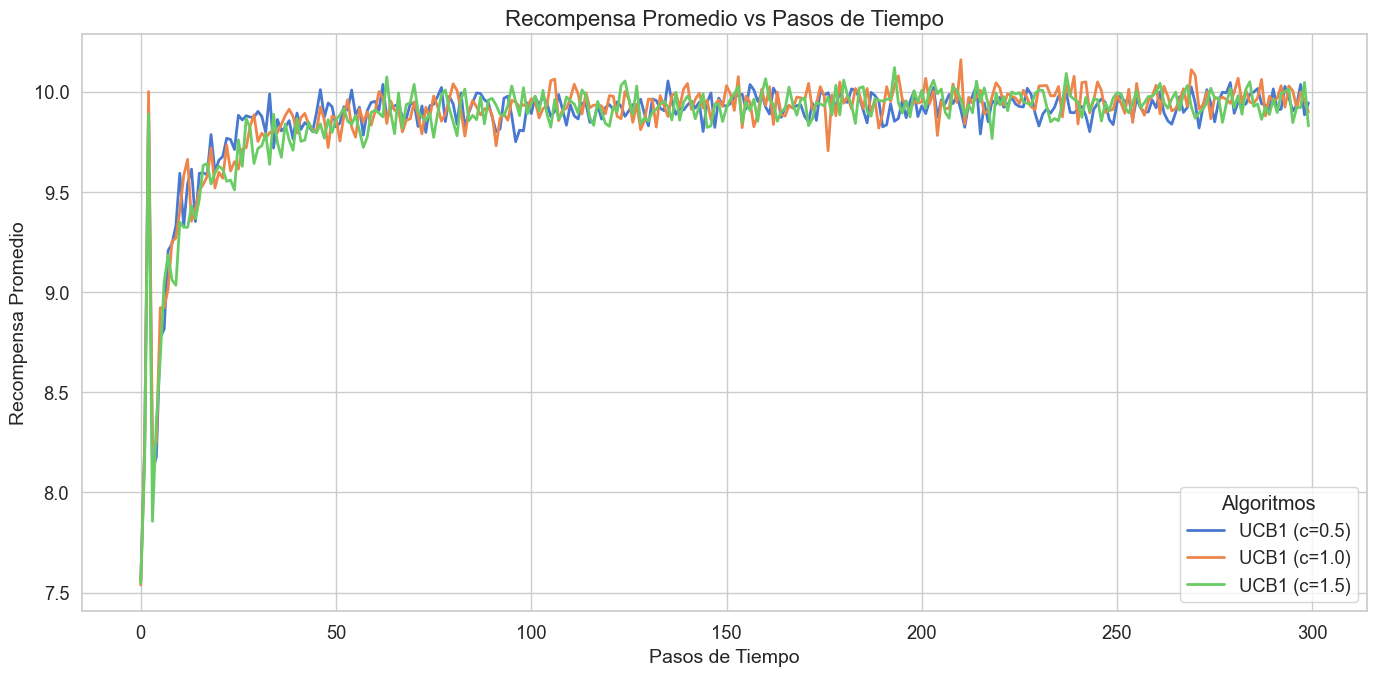

In [12]:
plot_average_rewards(steps, rewards_UCB1, algoritmos_ucb1)

En la gráfica anterior podemos ver el comportamiento del algoritmo UCB1 cuando se modifica su variable de exploración en cada uno de sus 300 pasos. En esta gráfica podemos observar cosas bastante evidentes, en primer lugar, es que la parametrización de la variable de exploración no afecta de forma palpable al comportamiento de cada una de las curvas.

Respecto a la convergencia, se puede observar que los niveles de convergencia se alcanzan con alrededor de los 50 pasos de tiempo y conforme se aumentan los pasos del tiempo no se observa una ganancia sustancial de la recompensa promedia.

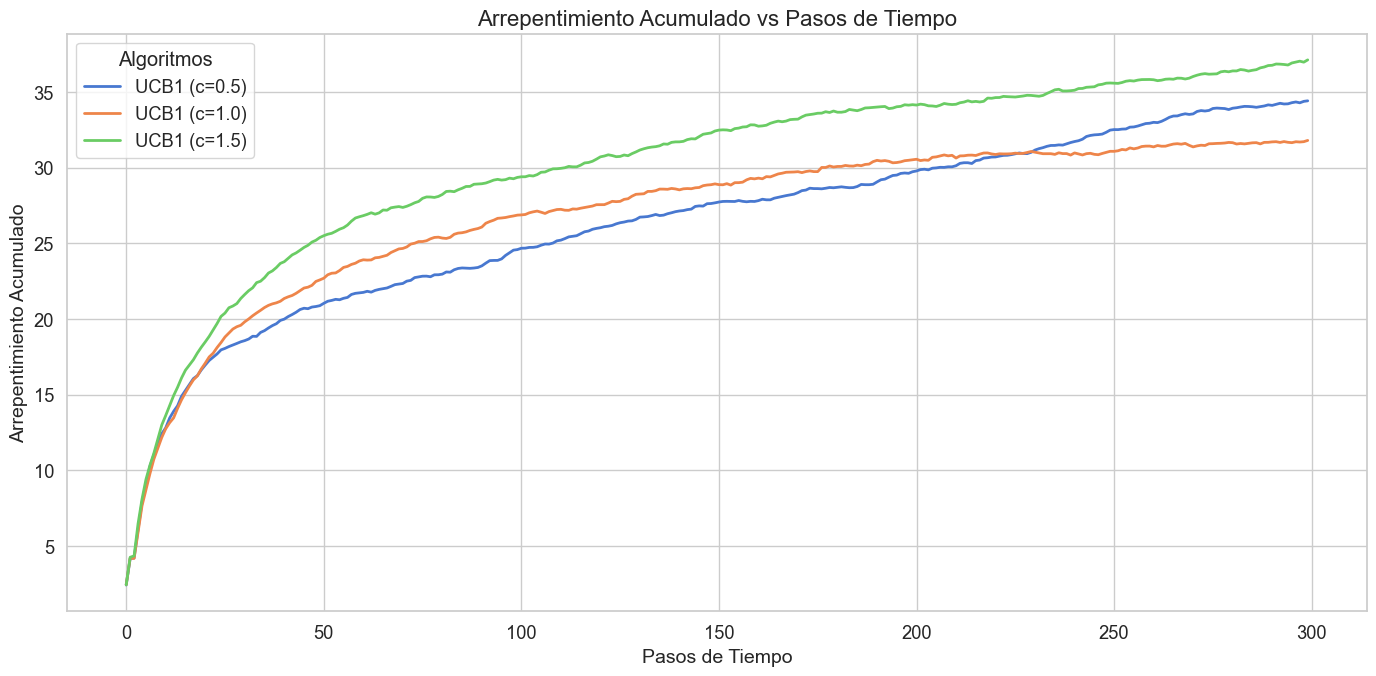

In [13]:
plot_regret(steps, cumulative_regret_per_algo_UCB1, algoritmos_ucb1)

Con esta gráfica, mostramos el arrepentimiento acumulado promedio por cada paso de tiempo en cada algoritmo UCB1 con la variable de explocación parametrizada. El arrepentimiento es una representación de la cuantificación de la perdida por no elegir constantemente el mejor brazo óptimo. Un algoritmo debería de tener el comportamiento de no elegir inicialmente la opción óptima pero conforme se aumentan los pasos de tiempo, la elección del brazo óptimo se debería de producir con mayor frecuencia. Con esta descripción, es fácil asumir que, la descripción de la curva debería seguir una forma logarítmica.

Lo que se puede ver con esta gráfica es que, efectivamente, dicha forma logarítmica se produce en cada caso. Es interesante observar que cuando la variable de exploración es de $0.5$ se produce un comportamiento bastante interesante, conretamente, lo que observamos es que inicialmente el error acumulado es más bajo que cuando la variable de exploración es $1.0$, sin embargo, a partir de aproximadamente 225 pasos, podemos ver que el error acumulado supera al error acumulado de la variable de exploración $1.0$. Con esto podemos decir que los niveles de convergencia de $c=0.5$ se encuentran significativamente más tardíos que cuando $c=1.0$. Con esto podemos observar que cuando la variable de exploración toma el valor por defecto, es el resultado que experimentalmente mejores valores nos da. 

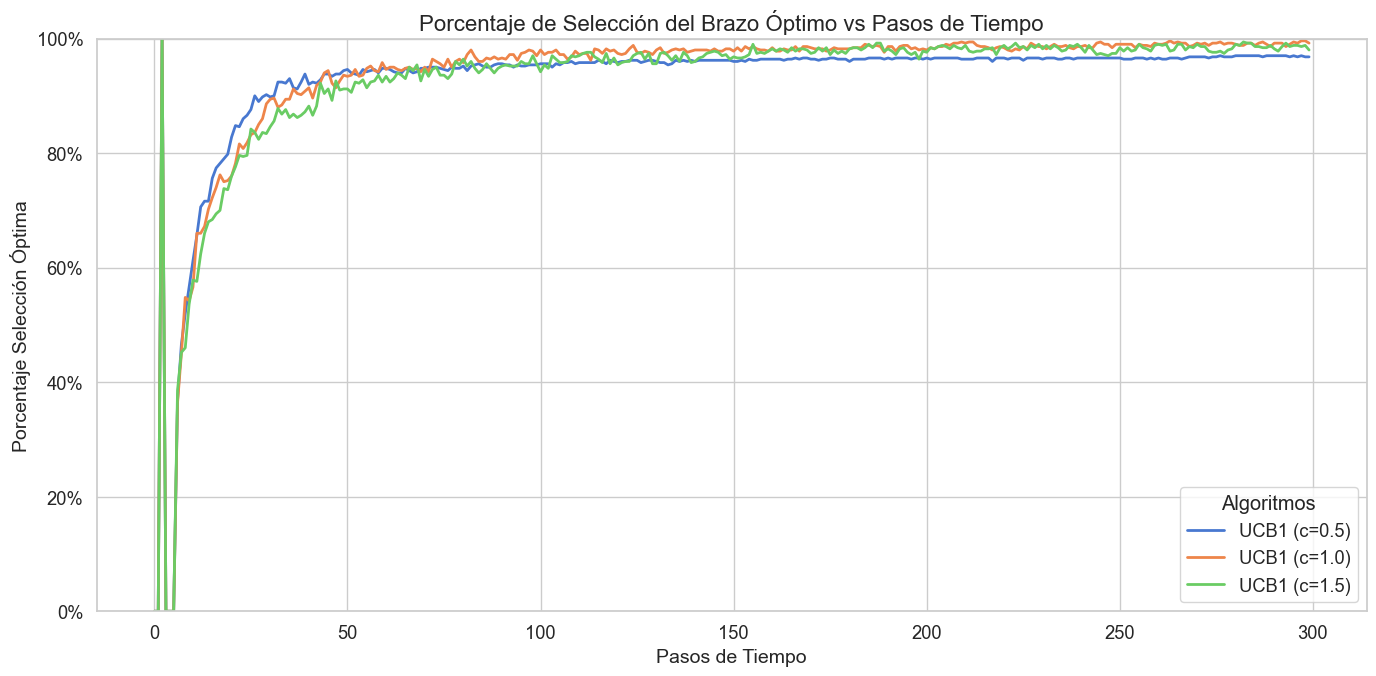

In [14]:
plot_optimal_selections(steps, optimal_selections_UCB1, algoritmos_ucb1)

Con esta gráfica mostramos el porcentaje de veces, dentro de las 500 ejecuciones, que el bandido escogió el brazo óptimo. Podemos observar que son muy parecidas las 3 curvas entre sí rozando prácticamente el 100% del porcentaje de selección del brazo óptimo sobre los 150 pasos de tiempo. Es importante anotar que la curva más distinta dentro de las 3 curvas es aquella en la que el parámetro de exploración $c$ es igual a $0.5$, también es interesante observar que es la que hace convergencia temprana respecto a las 3 cirvas y no have el **spike** observado con las otras 2 curvas.

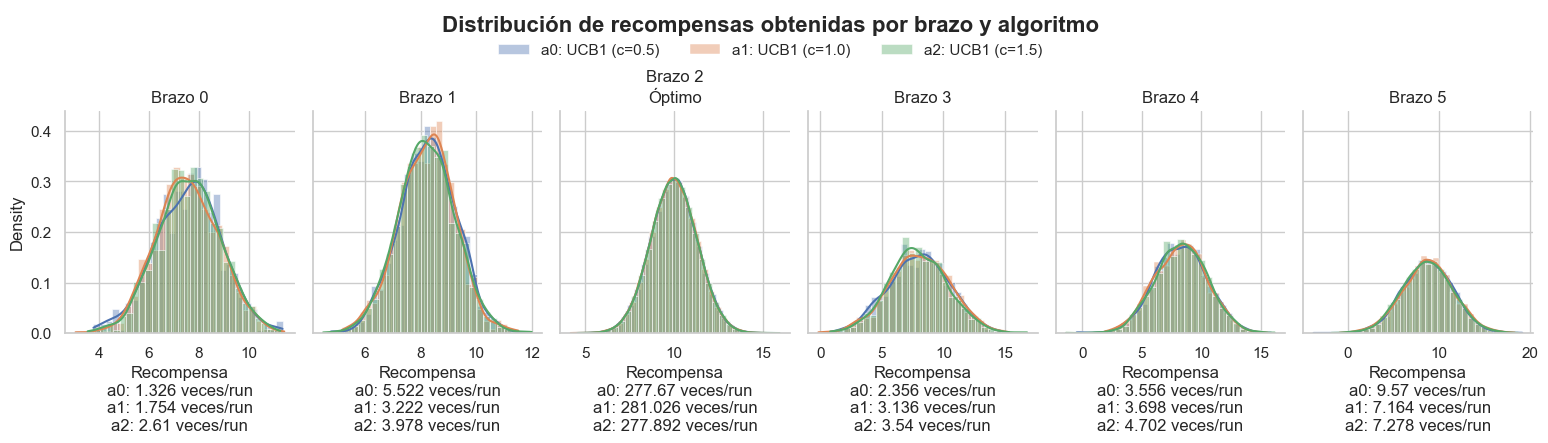

In [15]:
plot_arm_statistics(rewards_per_arm_per_algo_UCB1, algoritmos_ucb1, runs, optimal_arm_normal)

Esta última gráfica es un desglose de distribución de recompensas obtenidas por brazo y por cada algoritmo. Concretamente, mostramos un histograma de la distribución de recompensas obtenidas entre todas las veces que se escoge cada brazo. Mostramos los 3 algoritmos en capas, sin embargo, no s ellegan a distinguir del todo dado que las distribuciones son muy parecidas. Se puede observar que el Brazo 0 tiene algunas diferencias entre curvas, además del Brazo 1 y el Brazo 3.

Como podemos observar, el Brazo 2 es el óptimo y, además, es el brazo que se ha elegido más veces por cada algoritmo. Las 3 versiones de UCB1 tienen valores bastante similares de selección, sin embargo, la parametrización de la variable de exploración $c$ cuando es $0.5$ es el que menos veces ha sido seleccionado. El resto de brazos a tavés de las distintas parametrizaciones apenas son seleccionados, si eso, podemos decir que el brazo 5 es el sgeundo brazo más seleccionado.

### Distribución Binomial

Ahora, vamos a repetir los mismos experimentos utilizando el bandido de distribución binomial

In [16]:
np.random.seed(SEMILLA)
rewards_BC1_Bi, optimal_selections_BC1_Bi, cumulative_regret_per_algo_BC1_Bi, rewards_per_arm_per_algo_BC1_Bi = run_experiment(bandit_binomial, algoritmos_ucb1, steps, runs)

100%|██████████| 500/500 [00:03<00:00, 131.82it/s]


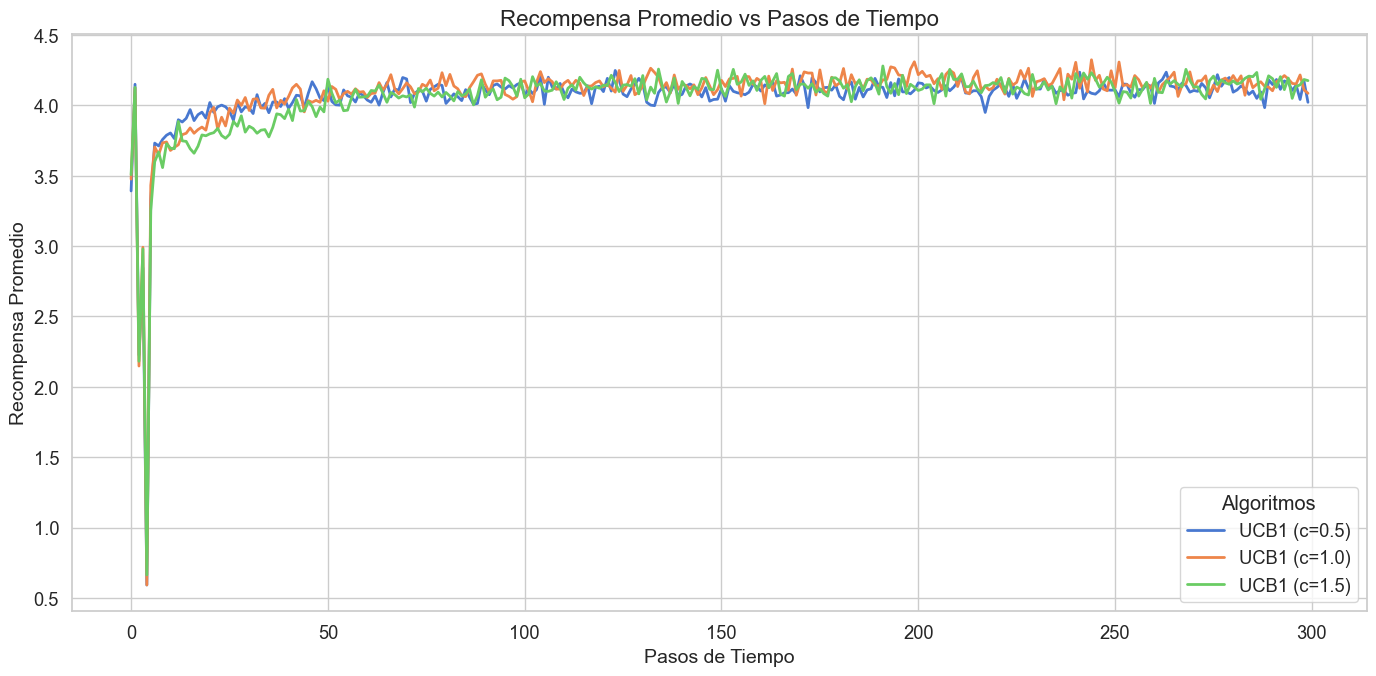

In [17]:
plot_average_rewards(steps, rewards_BC1_Bi, algoritmos_ucb1)

Podemos observar que el comportamiento de la curva se replica respecto a los brazos de distribución normal, es decir, mismos comportamientos independientemente de la parametrización de la variable de exploración y mismos niveles de convergencia. Se puede observar una diferencia clara respecto al anterior brazo, y es que, las recompensas promedias obtenidas se ven desplomadas sustancialmente.

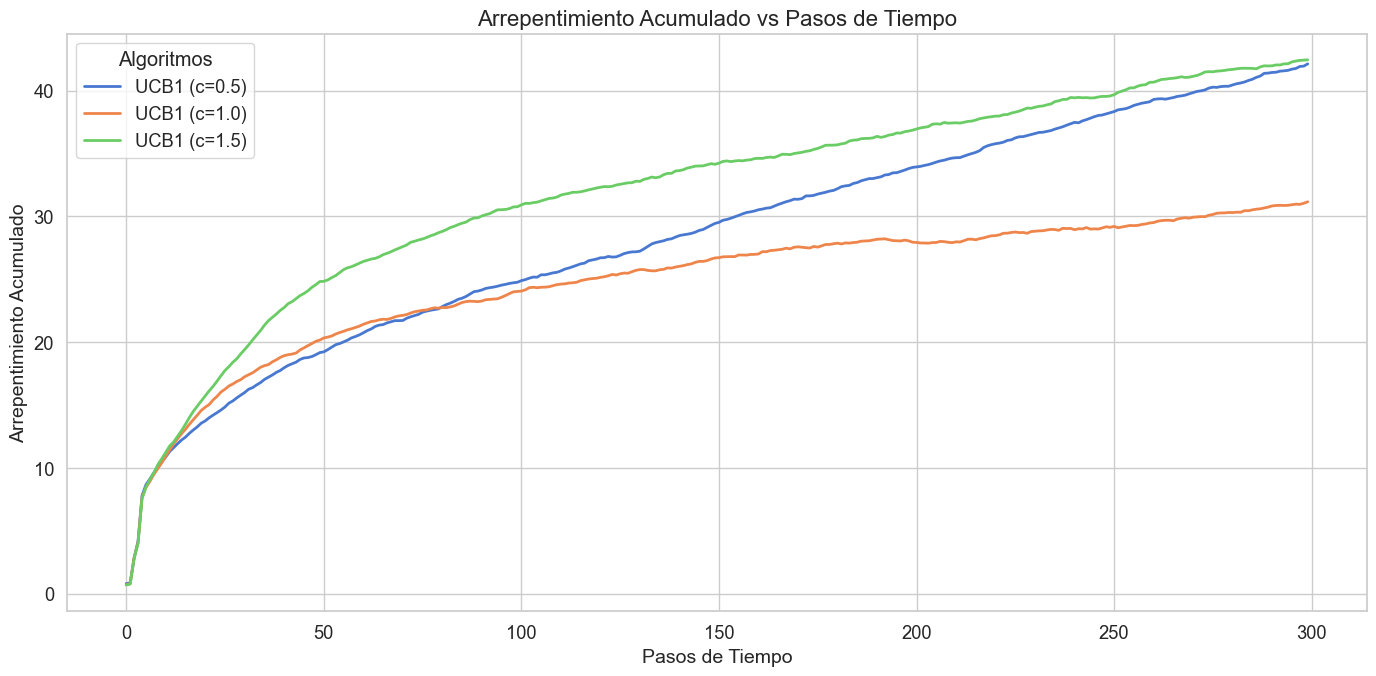

In [18]:
plot_regret(steps, cumulative_regret_per_algo_BC1_Bi, algoritmos_ucb1)

La gráfica del comportamiento muestra un comportamiento bastante interesante respecto a la anterior gráfica. Podemos observar que, nuevamente, la versión que mejor curva de arrepentimiento muestra es aquella en la que la variable de exploración se mantiene a $1.0$, sin embargo, podemos ver que inicialmente cuando nuestra variable de exploración es $0.5$, los valores de arrepentimiento son los mejores, pero rápidamente, en torno a 75 pasos de tiempo es peor que la variable de exploración $1.0$ e incluso si se dejara en ejecución más pasos de tiempo con una gran probabilidad sería la peor versión de las 3 curvas expuestas.

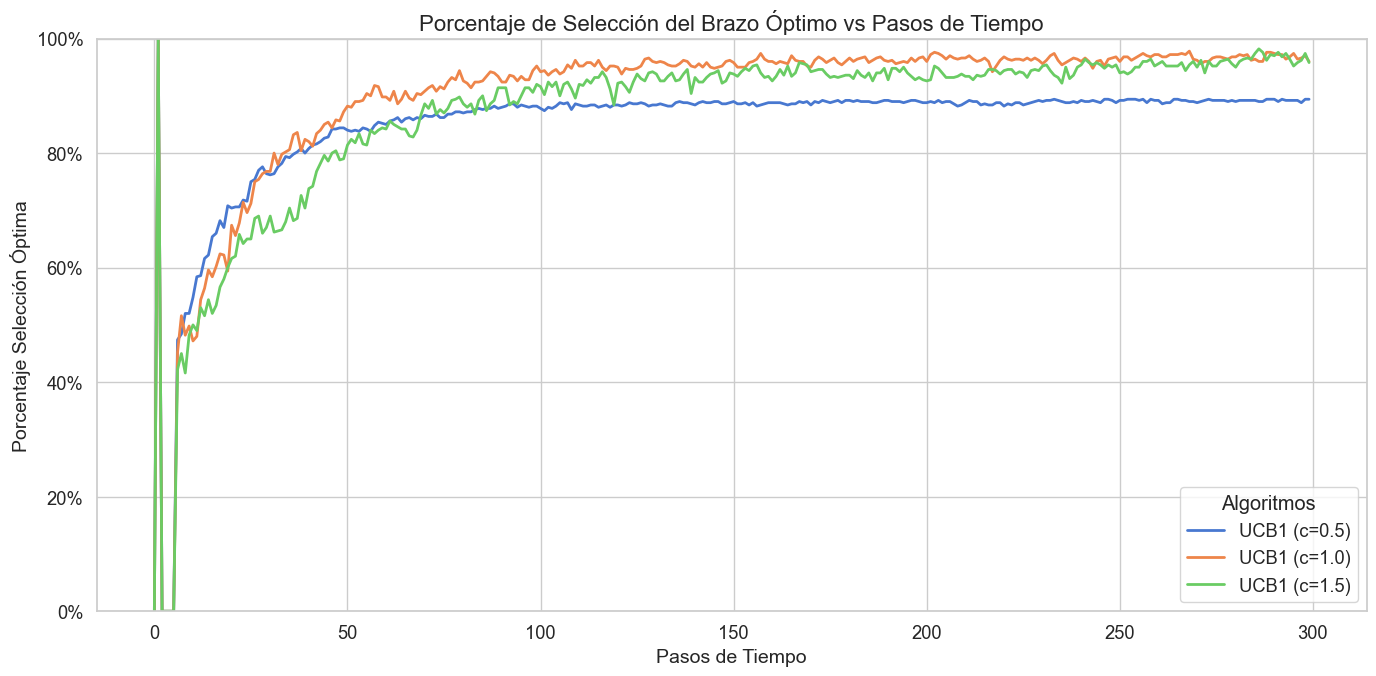

In [19]:
plot_optimal_selections(steps, optimal_selections_BC1_Bi, algoritmos_ucb1)

Si bien, observamos nuevamente que las curvas de UCB1 con las variables de exploración cuando son $1.5$ o $1.0$, podemos ver que claramente es superior cuando la variable de exploración $1.0$. También observamos que si bien nos encontramos cerca del 100% del porcentaje de selección del brazo óptimo en las 3 curvas, podemos ver que sus puntos de convergencia se sitúan ligeramente por debajo que lo expuestos con la distribución normal. UCB1 cuando su variable de exploración es $0.5$ muestra más diferencias que el resto de curvas, situándose por debajo del 90% en su convergencia. Con esto, podemos concluir que cuando nuestra variable de exploración es concretamente $1.0$ es cuando el algoritmo mejor aprende.

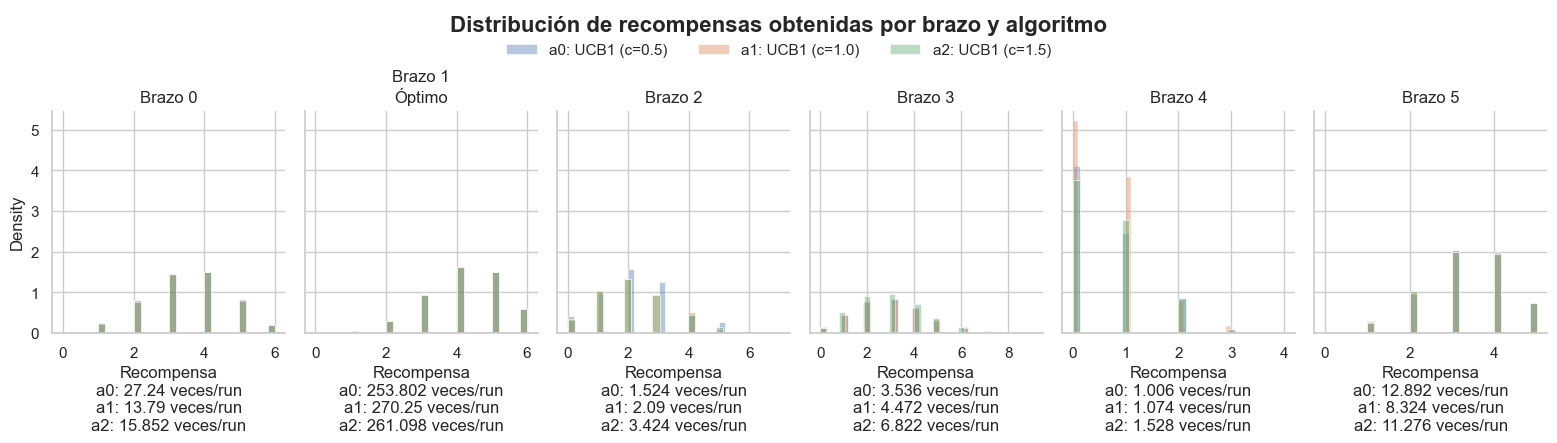

In [20]:
plot_arm_statistics(rewards_per_arm_per_algo_BC1_Bi, algoritmos_ucb1, runs, optimal_arm_binomial, kde=False)

Con esta última gráfica se vuelve a ver en cierta manera el mismo patrçon que con la distribución normal, es decir, el brazo óptimo tiene una alta tendencia a ser elegido, siendo este el Brazo 1. Podemos observar, eso si, una diferencia bastante palpable respecto a la distribución normal, y es que, uno de los brazos no óptimos es seleccionado bastante más veces que en cualquier otro brazo de la distrbución normal. También podemos ver que los brazos no siguen una distribución normal, debido a que estamos ante una distribución con resutlados discretos.

Nuevamente, al igual que con los brazos de distribución normal, el brazo con la variable de exploración escogida a $0.5$ tiene tendencia a elegir bastante más veces el brazo equitocado, bajo la excepción del Brazo 3 y del Brazo 4, donde son elegidos con más frecuencia con la variable de exploración a $1.5$.

### Distribución Bernoulli

Para terminar con el primer algoritmo de la familia de UCB, vamos a comprobar que tal se comporta con la distribución de Bernoulli

In [44]:
np.random.seed(SEMILLA)
rewards_BC1_Be, optimal_selections_BC1_Be, cumulative_regret_per_algo_BC1_Be, rewards_per_arm_per_algo_BC1_Be = run_experiment(bandit_bernoulli, algoritmos_ucb1, steps, runs)

100%|██████████| 500/500 [00:03<00:00, 156.19it/s]


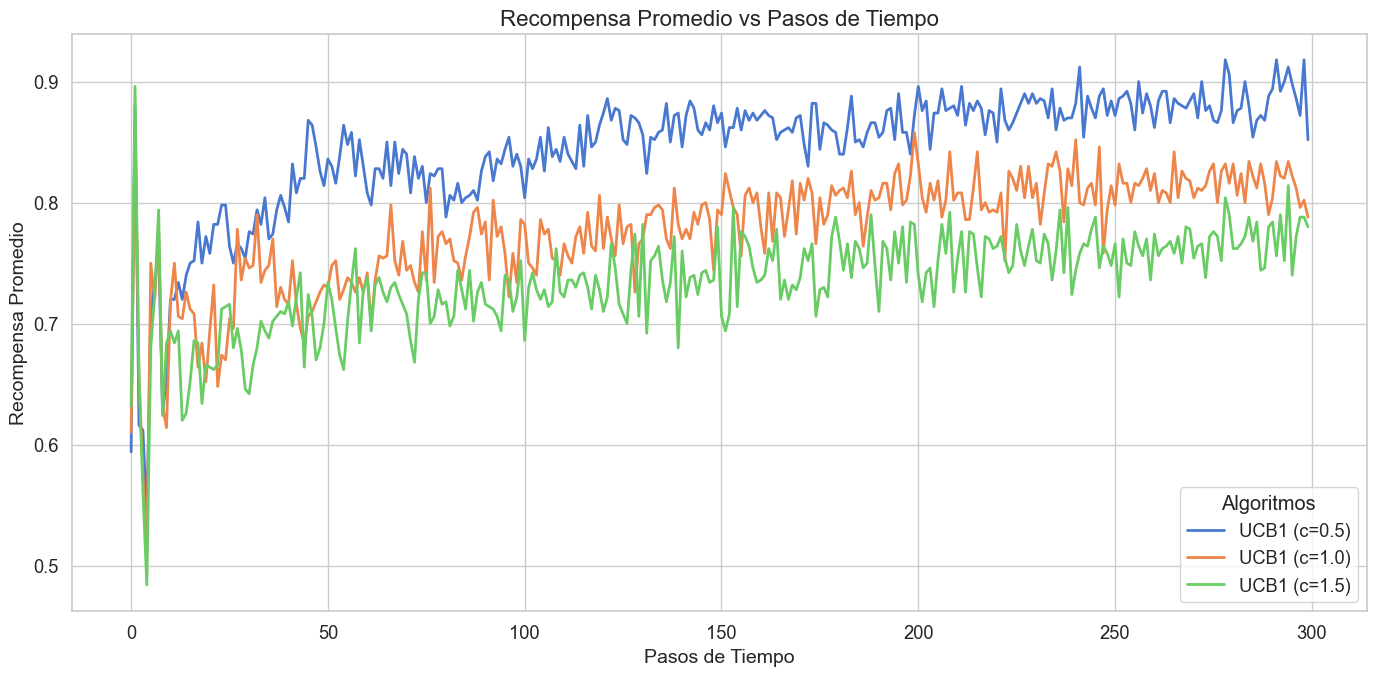

In [45]:
plot_average_rewards(steps, rewards_BC1_Be, algoritmos_ucb1)

En este caso si que se pueden evidenciar diferencias palpables con solamente analizar las recompensas promedio del algoritmo UCB1. Concretamente, observamos que la mejor versión para la distribución Bernoulli resulta de utilizar como variable de exploración $c=0.5$. De forma general se observa que los niveles de convergencia se consiguen de forma bastante más tardía que con los otros brazos, obteniéndose en torno a los 200 pasos. También se palpa una mayor inestabilidad con **spikes** a lo largo de las 3 parametrizaciones realizadas, indicando que al bandido a través de los 3 casos de estudio le cuesta más aprender aquel brazo que sea óptimo.

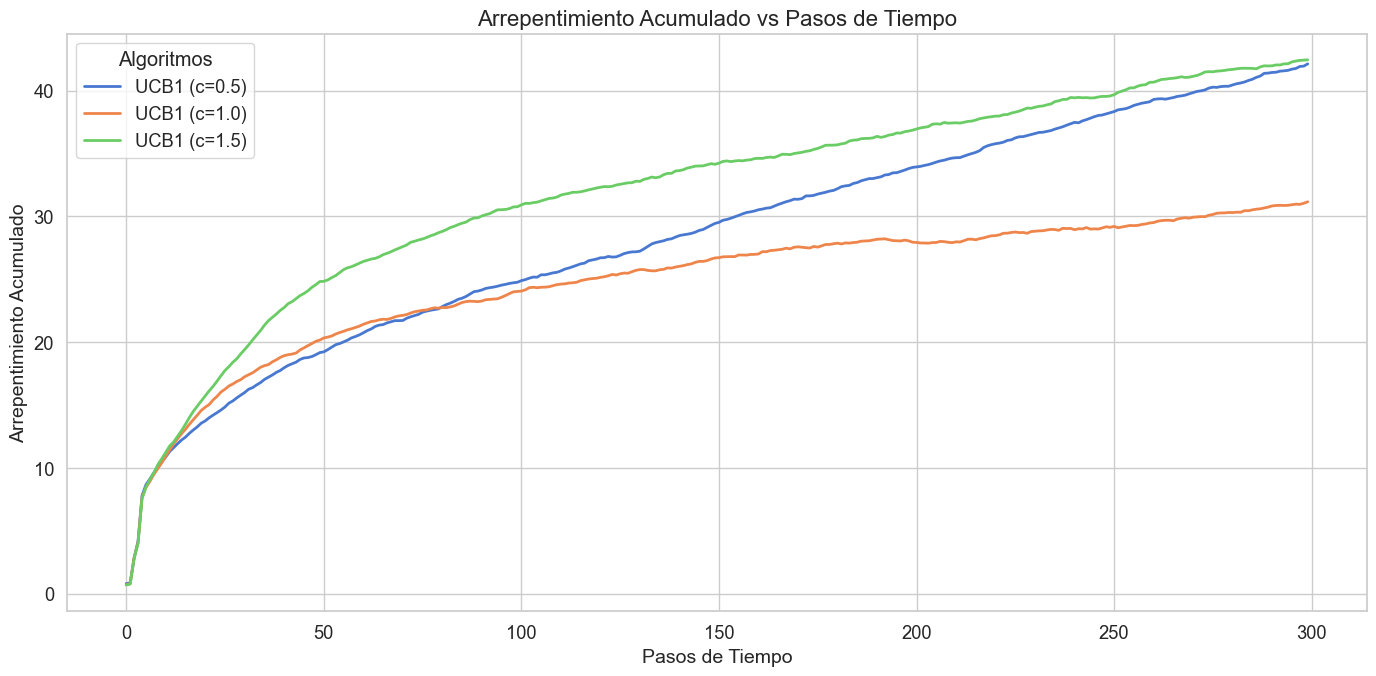

In [27]:
plot_regret(steps, cumulative_regret_per_algo_BC1_Be, algoritmos_ucb1)

Podemos ver que las curvas del arrepentimiento siguen exactamente los mismos patrones que la distribución binomial, haciendo que muy probablemente sea UCB1 con $c=0.5$ el peor valor y siendo UCB1 con el valor por defecto de exploración el mejor.

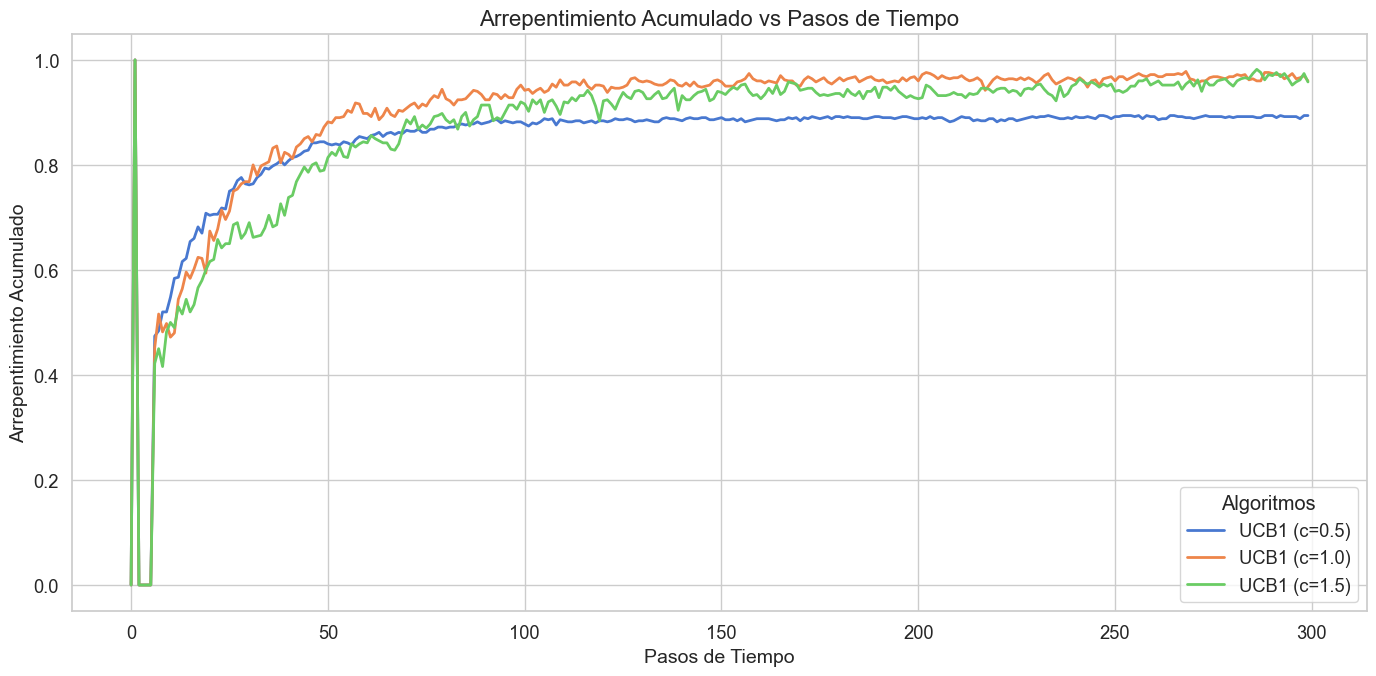

In [28]:
plot_regret(steps, optimal_selections_BC1_Be, algoritmos_ucb1)

Podemos observar nuevamente que se repiten los patrones analizados anteriormente respecto a la curva de arrepentimiento. Además, odemos observar que si se dejarán más pasos para UCB1 cuando la variable de exploración es $1.5$, obtenemos un arrepentimiento acumulado mayor.

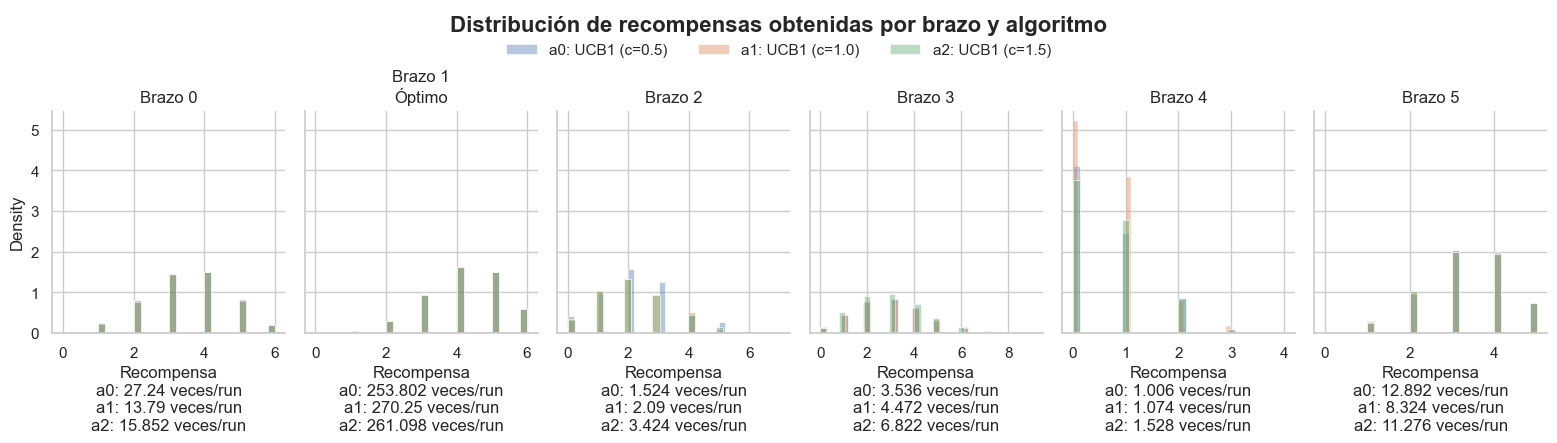

In [29]:
plot_arm_statistics(rewards_per_arm_per_algo_BC1_Be, algoritmos_ucb1, runs, optimal_arm_bernoulli, kde=False)

Para terminar, el brazo óptimo es el que evidentemente más se selecciona, mientras que el resto de brazo no se seleccionan. El único brazo que más selecciona que no sea óptimo es el Brazo 0, concretamente, para el UCB1 con la variable de exploración a $0.5$ este brazo es el más seleccionado. Podemos observar, además, que el Brazo 5 es el segundo brazo no óptimo menos seleccionado, cuya selección ocurre más con la variable de exploración a $0.5$

Con todo esto podemos observar que las salidas producidas son muy parecidas que cuando tenemos distribuciones binomiales o normales, sin embargo, el mejor método dentro de todos los existentes para este algoritmo es el de los bandidos con distribución normal.

## Análisis UCB2

En esta sección nos dedicamos al estudio del segundo algoritmo de la familia UCB, concretamente UCB2 con todos los tipos de bandidos. Para cada uno, vamos a ejecutar el algoritmo con valores distintos del parámetro $\alpha$. Concretamente, vamos a probar con valores comprendidos entre $0$ y $1$, concretamente: $0.25$, $0.5$, $0.75$

In [30]:
algoritmos_ucb2 = [UCB2(k=k, alpha=0.25), UCB2(k=k, alpha=0.5), UCB2(k=k, alpha=0.75)]

### Distribución Normal

En primer lugar, vamos a realizar las ejecuciones de todos los algoritmos con el bandido cuyos brazos sigan la distribución normal

In [31]:
np.random.seed(SEMILLA)
rewards_UCB2, optimal_selections_UCB2, cumulative_regret_per_algo_UCB2, rewards_per_arm_per_algo_UCB2 = run_experiment(bandit_normal, algoritmos_ucb2, steps, runs)

  0%|          | 0/500 [00:00<?, ?it/s]c:\Users\jorge\EML_RL_LucasOrtiz\k_brazos\src\algorithms\ucb_2.py:41: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt((1 + self.alpha) * np.log(np.e * n / tau_r) / (2 * tau_r))
100%|██████████| 500/500 [00:01<00:00, 305.61it/s]


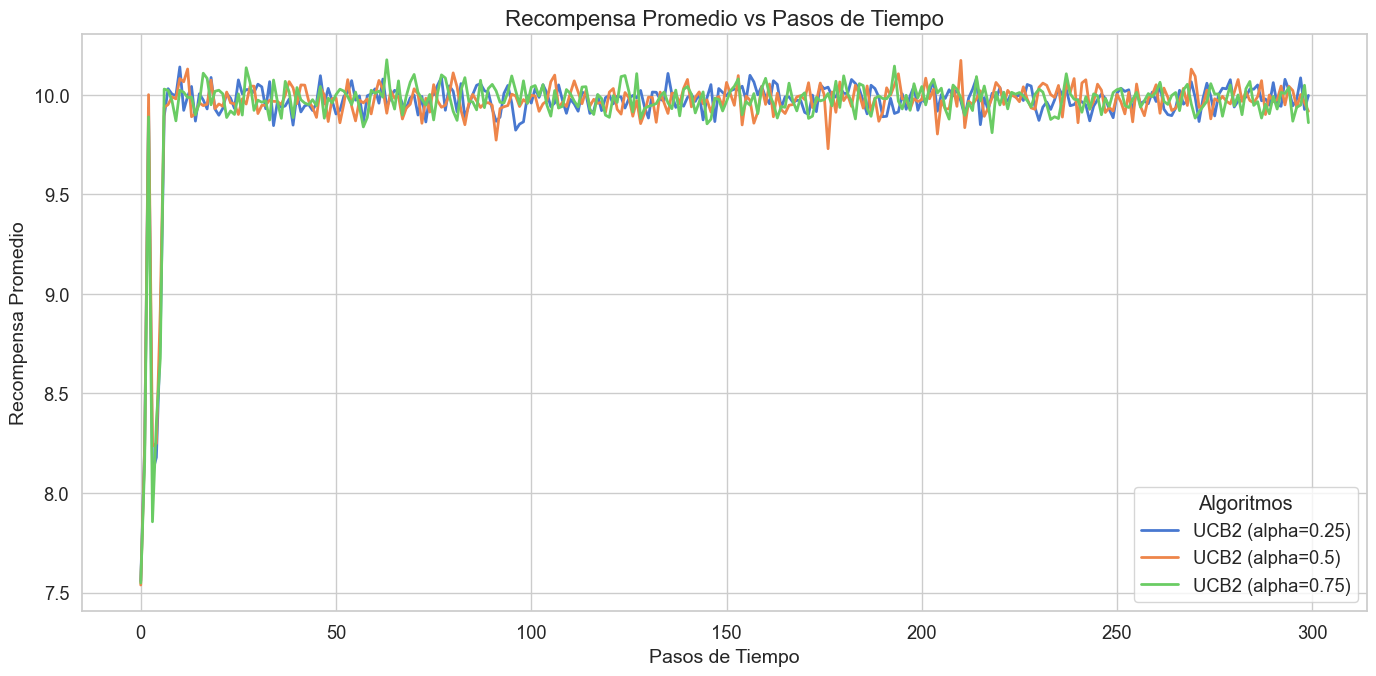

In [32]:
plot_average_rewards(steps, rewards_UCB2, algoritmos_ucb2)

Con la segunda iteración del algoritmo UCB, es decir, UCB2, podemos observar que los niveles de convergencia se hacen en prácticamente menos de 20 épocas con cualquier valor escogido para nuestro $\alpha$. Esto demuestra la superioridad que este este algoritmo frente a UCB1. La velocidad de aprendizaje es extremadamente alta.

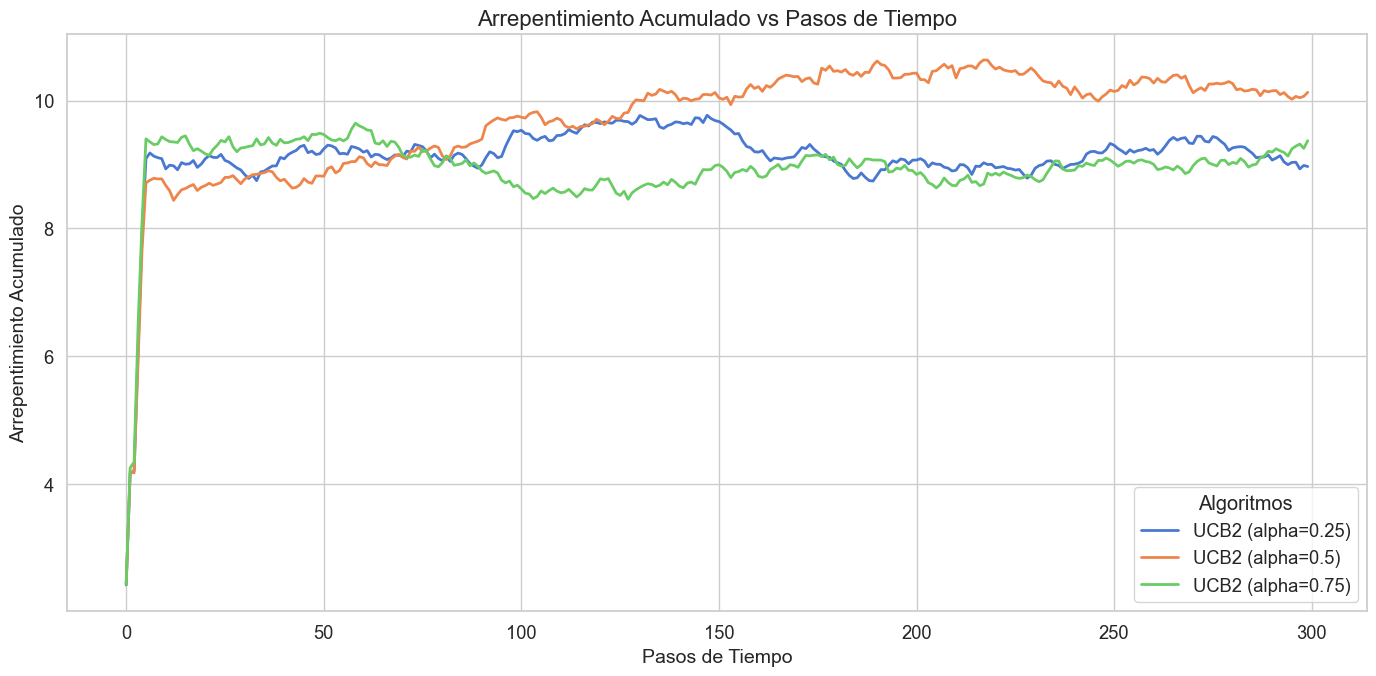

In [33]:
plot_regret(steps, cumulative_regret_per_algo_UCB2, algoritmos_ucb2)

Respecto al arrepentimiento, podemos observar algo un tanto distinto al patrón observado con UCB1. Concretamente, se puede ver que si bien la convergencia se hace con aproximadamente, menos de 10 pasos de tiempo, a partir de un momento, que es en torno a los 100 pasos de tiempo, se producen cambios en el arrepentimiento acumulado, subiendo en el caso de $\alpha=0.25$ y $\alpha=0.75$, sin embargo, luego vuelve a bajar en $\alpha=0.25$, un patrón que resulta un tanto curioso. Respecto a $\alpha=0.75$ se puede observar que tras llegar a esa convergencia inicial y tras producir el cambio en torno a los 100 pasos, se puede ver que el arrepentimiento acumuado baja y lentamente se ve incrementado, hasta tener una tasa de arrepentimiento acumulado superior a la de $\alpha=0.25$

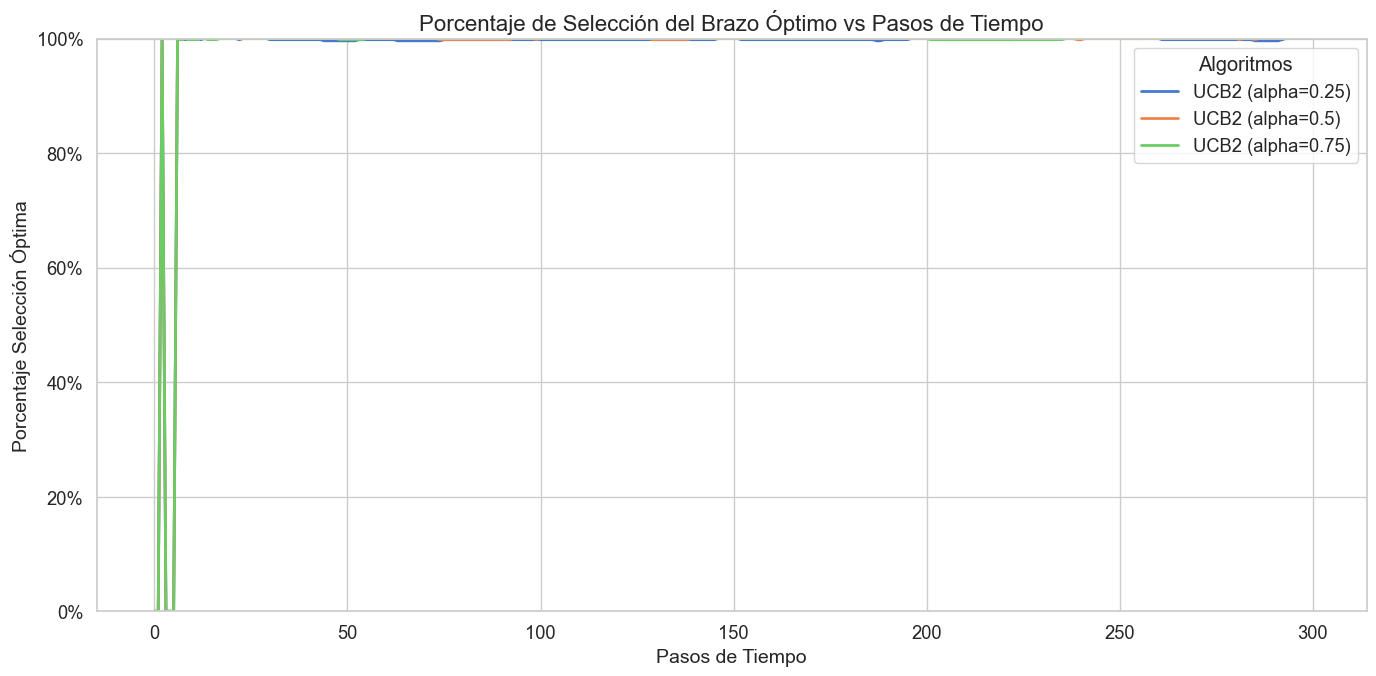

In [34]:
plot_optimal_selections(steps, optimal_selections_UCB2, algoritmos_ucb2)

Respecto al porcentaje de selección del brazo óptimo a lo largo de los pasos del tiempo, podemos observar que de forma general se selecciona desde los niveles de convergencia el brazo óptimo. Podemos observar que la peor versión del algoritmo UCB2 se da cuando $\alpha=0.25$. En el resto de casos prácticamente se mantiene al 100% la selección del brazo óptimo

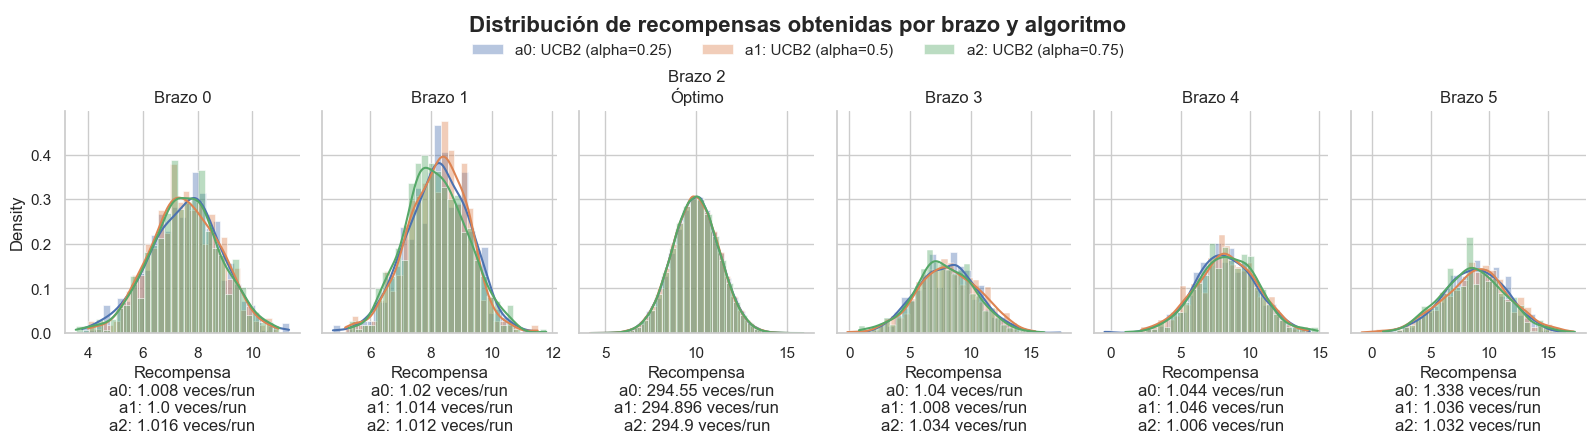

In [35]:
plot_arm_statistics(rewards_per_arm_per_algo_UCB2, algoritmos_ucb2, runs, optimal_arm_normal)

Podemos comprobar con la distribución de recompensas que casi siempre se selecciona el brazo 2 como brazo óptimo, y de forma extremadamente casual se selecciona cualquier otro brazo. En media, los brazos no óptimos se seleccionan 1 vez por cada ejecución y sus distribuciones son un tanto anomalas respecto a las del brazo óptimo a consecuencia de la falta de datos de dicho brazo para poder dibujar más concretamente su distribución.

### Distribución Binomial

Ahora, es el turno del análisis de UCB2 cuando se aplica la distribución binomial.

In [36]:
np.random.seed(SEMILLA)
rewards_BC2_Bi, optimal_selections_BC2_Bi, cumulative_regret_per_algo_BC2_Bi, rewards_per_arm_per_algo_BC2_Bi = run_experiment(bandit_binomial, algoritmos_ucb2, steps, runs)

 12%|█▏        | 62/500 [00:00<00:01, 303.68it/s]c:\Users\jorge\EML_RL_LucasOrtiz\k_brazos\src\algorithms\ucb_2.py:41: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt((1 + self.alpha) * np.log(np.e * n / tau_r) / (2 * tau_r))
100%|██████████| 500/500 [00:01<00:00, 300.42it/s]


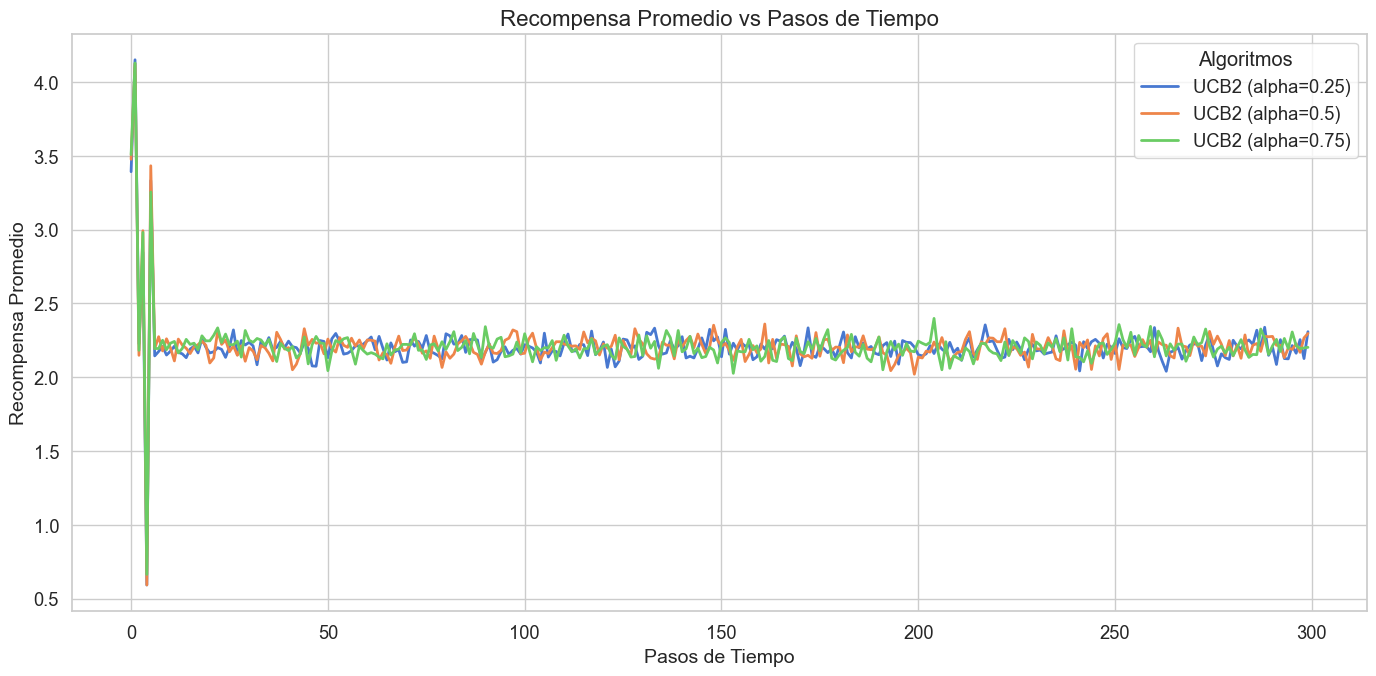

In [37]:
plot_average_rewards(steps, rewards_BC2_Bi, algoritmos_ucb2)

Podemos observar que las recompensas obtenidas son totalmente anómalas que las obtenidas en cualquier distribución de bandido con UCB1 o que con UCB2 con la distribución normal. Concretamente, lo que observamos es un estancamiento claro del algoritmo que no es capaz de aprender correctamente, haciendo convergencia de forma bastante precoz y manteniéndose a niveles constantes. Claramente, observamos que el aprendizaje que realiza el bandido es bastante malo. El patrón se repite independientemente de los valores elegidos para la variable $\alpha$

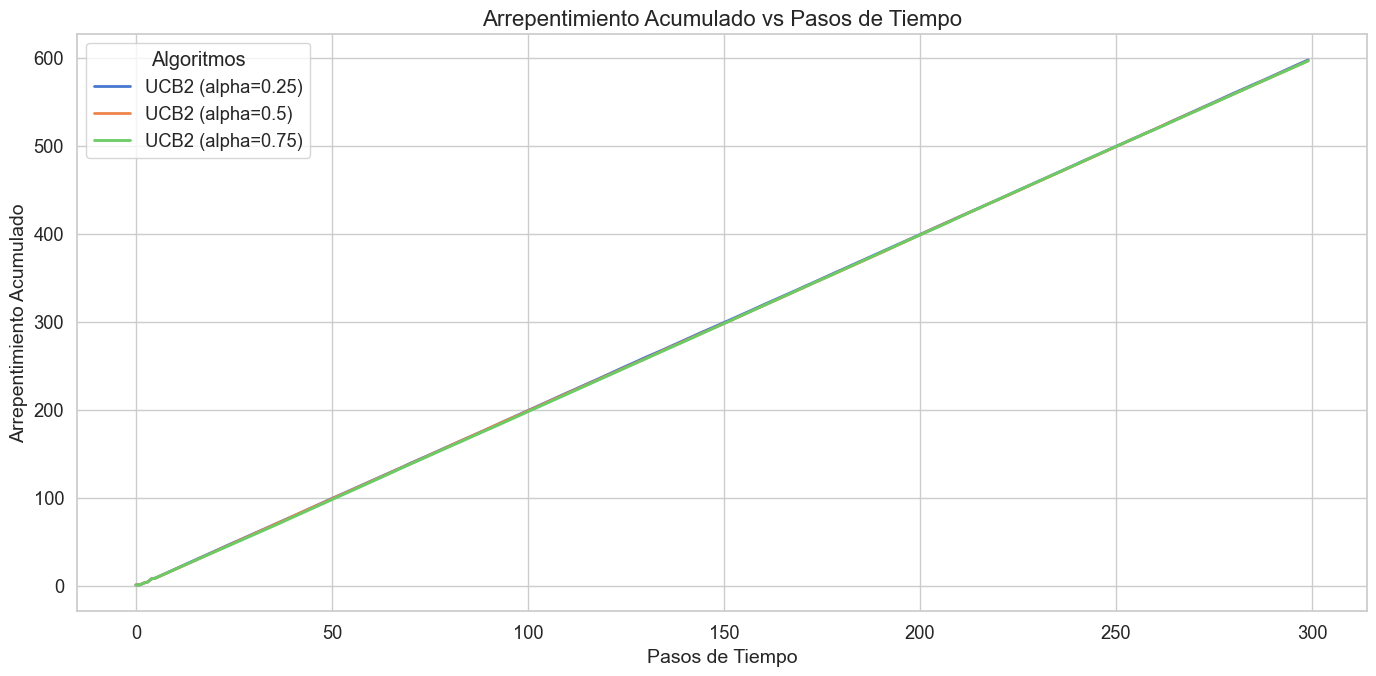

In [38]:
plot_regret(steps, cumulative_regret_per_algo_BC2_Bi, algoritmos_ucb2)

Podemos ver que ya no se respeta la curva del arrepentimiento descrita en cualquiera de los ejemplos ejecutados anteriormente. Esta vez, lo que se observa es una línea totalmente recta conforme se avanzan en los pasos que es prácticamente idéntica con independencia de los valores escogidos para la variable $\alpha$, algo que evidencia el mal aprendizajee que realiza nuestro bandido.

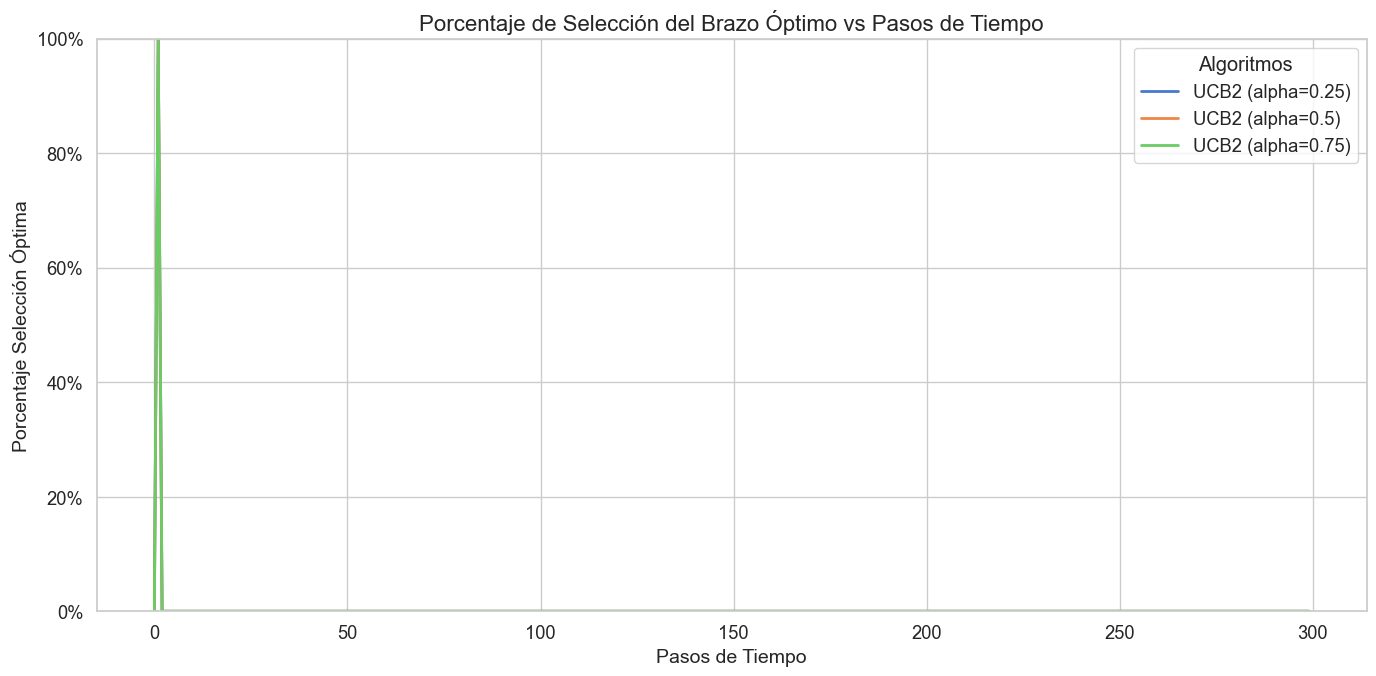

In [39]:
plot_optimal_selections(steps, optimal_selections_BC2_Bi, algoritmos_ucb2)

Podemos observar con este algoritmo, que nunca se elige el brazo óptimo, es más, salvo el muy inicio por metodología de exploración, no se vuelve a elegir el brazo óptimo en cualquier ejecución.

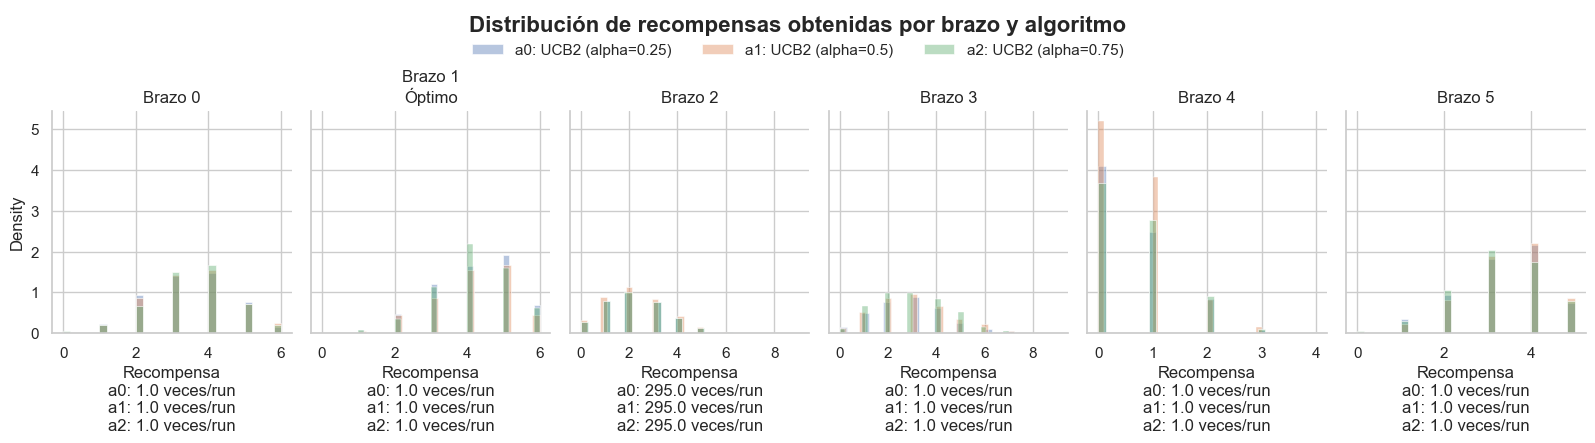

In [40]:
plot_arm_statistics(rewards_per_arm_per_algo_BC2_Bi, algoritmos_ucb2, runs, optimal_arm_binomial, kde=False)

Con esta gráfica podemos ver concretamente que es lo que esta ocurriendo. Concretamente, lo que pasa es que se está escogiendo constantemente aquel brazo que no es óptimo. También podemos ver que las veces que cada brazo es escogido a lo largo de todas las parametrizaciones de UCB2 es el mismo, es decir, cada brazo es escogido 1 vez, salvo el 2, que es escogido el resto de veces. Con esto se evidencia que el método de la distribución Binomial junto al algoritmo UCB2 resulta de una muy mala combinación para el problema de los bandidos.

### Distribución Bernoulli

Para finalizar el análisis de UCB2, pasemos a observar que tal se comporta este algoritmo con la distribución de Beroulli

In [42]:
np.random.seed(SEMILLA)
rewards_BC2_Be, optimal_selections_BC2_Be, cumulative_regret_per_algo_BC2_Be, rewards_per_arm_per_algo_BC2_Be = run_experiment(bandit_bernoulli, algoritmos_ucb2, steps, runs)

 53%|█████▎    | 263/500 [00:00<00:00, 322.22it/s]c:\Users\jorge\EML_RL_LucasOrtiz\k_brazos\src\algorithms\ucb_2.py:41: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt((1 + self.alpha) * np.log(np.e * n / tau_r) / (2 * tau_r))
100%|██████████| 500/500 [00:01<00:00, 321.53it/s]


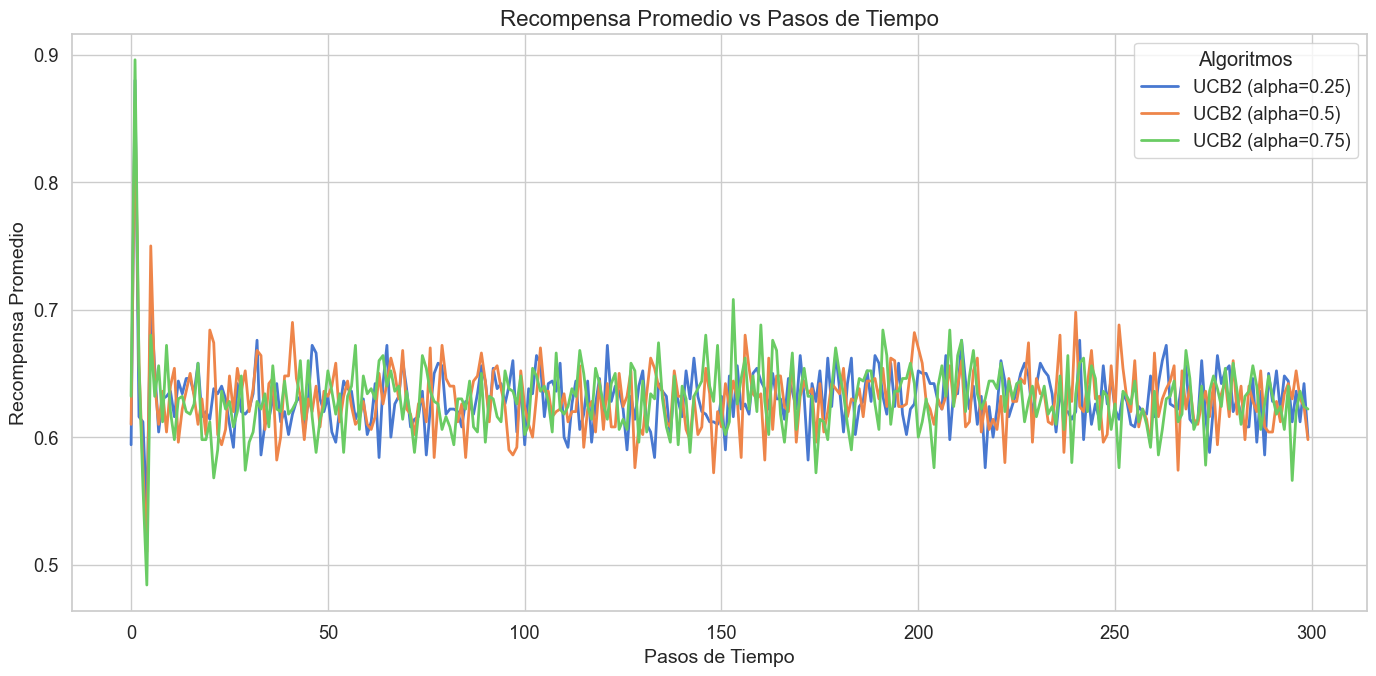

In [43]:
plot_average_rewards(steps, rewards_BC2_Be, algoritmos_ucb2)

Nuevamente, al igual que con la versión de la distribución de la Binomial, vemos un estancamiento generalizado del aprendizaje, sin embargo, a diferencia de la distribución Binomial, este estancamiento se produce en valores aún más bajos, es decir, en vez de encontrarnos en una situación de estancamiento en torno a $2.25$, nos encontramos en un estancamiento de recompensa promedio entorno al valor $0.65$. Esto indica que muy probablemente estemos escogiendo aún peores brazos que los escogidos con la distribución binomial. También vemos, al igual que con la distribución binomial, que independientemente de la versión del algoritmo que hayamos escogido los valores producidos son los mismos.

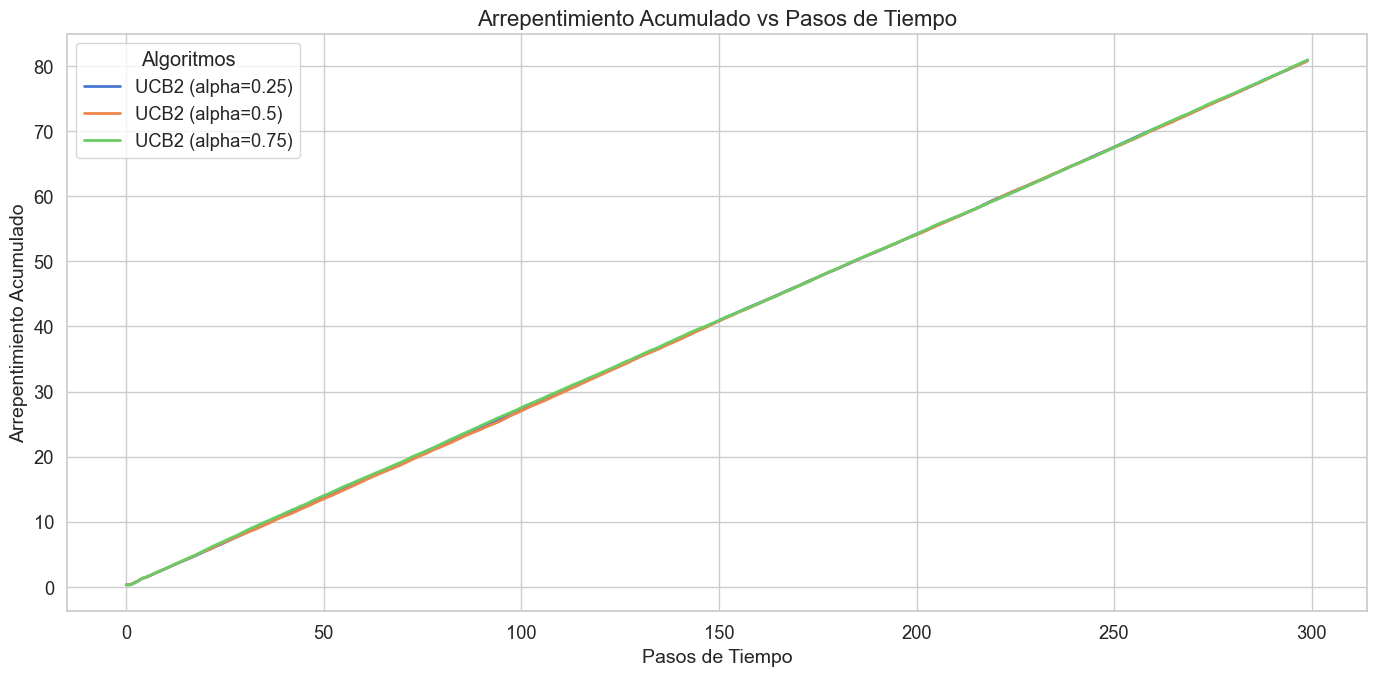

In [46]:
plot_regret(steps, cumulative_regret_per_algo_BC2_Be, algoritmos_ucb2)

Tal y como se produce con el sistema de distribución Binomial, el arrepentimietno acumulado producido sigue una línea perfectamente recta que se replica con independencia de la versión del algoritmo parametrizado que utilicemos. Sin embargo, a diferencia de la versión anterior, tenemos que el arrepentimiento acumulado en su valor extremo de los pasos del tiempo es bastante inferior al ya denotado por la distribución binomial, es decir, tenemos como máximo un arrepentimiento caumulado de cerca de $80$ frente a los $600$ de la distribución Binomial.

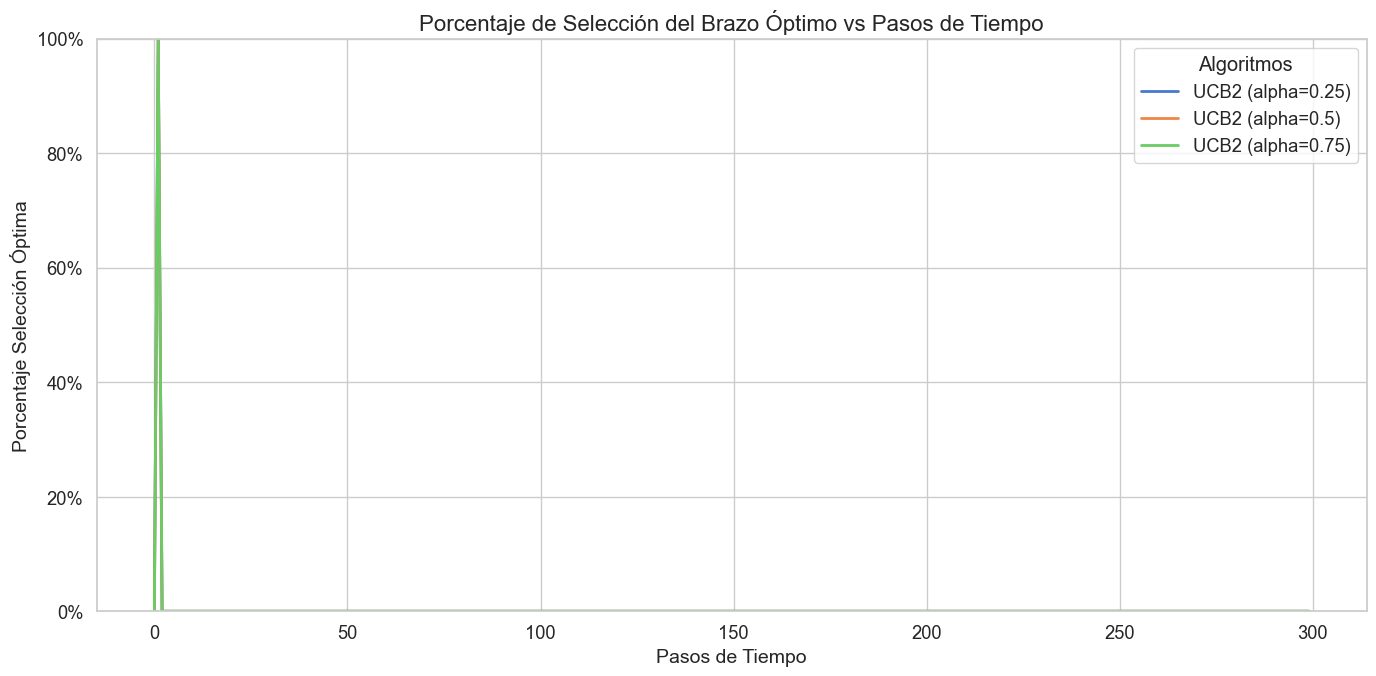

In [47]:
plot_optimal_selections(steps, optimal_selections_BC2_Be, algoritmos_ucb2)

Nuevamente, podemos ver que lo que esperábamos se cumple, es decir, nunca es seleccionado el brazo óptimo, únicamente en aquel intante en el que se exploran todos y cada uno de los brazos que contenga nuestro bandido, pero nunca se vuelve a seleccionar el brazo óptimo.

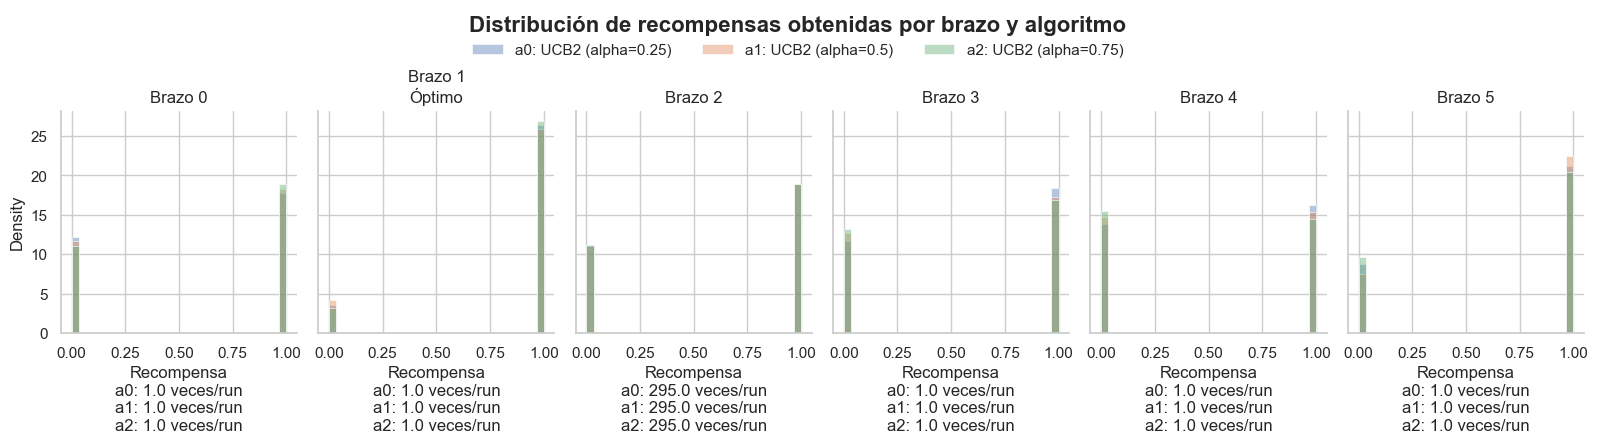

In [48]:
plot_arm_statistics(rewards_per_arm_per_algo_BC2_Be, algoritmos_ucb2, runs, optimal_arm_bernoulli, kde=False)

Como podemos ver, las recompensas producidas para el Brazo 2 que es seleccionado por cada parametrización del algoritmo $295$ de las $300$ totales y el resto $1$ vez por cada brazo, tiene tendencia a devolvernos como recompensa $0$. Esto explica el por qué obtenemos unos valores de recompensa promedia tan bajos.

## Análisis UCB1-Tuned

### Distribución Normal

### Distribución Binomial

### Distribución Bernoulli

## Conclusiones

## Referencias